In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

# Load the preprocessed data set

In [ ]:
data_path = Path("/content/drive/My Drive/ML/sri_lanka_weather_encoded.csv")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (147480, 56)


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,rainfall_class,rainfall_class_encoded,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,2.0,30.0,22.7,26.1,34.4,25.2,29.2,20.92,0.0,11.7,27.4,4.58,16.0,2010.0,1.0,1.0,4.0,1.0,0.0,11.716667,0.5,0.866025,0.342020,0.939693,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,51.0,29.9,23.5,26.2,33.8,26.2,29.8,17.71,1.0,13.0,27.0,3.84,16.0,2010.0,1.0,2.0,5.0,1.0,1.0,11.733333,0.5,0.866025,0.406737,0.913545,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,51.0,29.5,23.2,26.0,34.3,26.3,29.9,17.76,3.0,12.3,27.4,3.65,16.0,2010.0,1.0,3.0,6.0,1.0,1.0,11.716667,0.5,0.866025,0.275637,0.961262,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2.0,28.9,21.9,25.3,31.6,23.4,27.8,16.50,0.0,17.0,34.6,3.79,16.0,2010.0,1.0,4.0,0.0,1.0,0.0,11.733333,0.5,0.866025,-0.069756,0.997564,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.0,28.1,21.3,24.5,30.1,23.1,26.1,23.61,0.0,18.7,37.1,4.97,16.0,2010.0,1.0,5.0,1.0,1.0,0.0,11.733333,0.5,0.866025,-0.087156,0.996195,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


# **Feature selection**

In [ ]:
target_col = "rainfall_class_encoded"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (147480, 55)
Target shape: (147480,)


In [ ]:
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric:
    print("Dropping non-numeric columns:", non_numeric)
    X = X.drop(columns=non_numeric)
else:
    print("All feature columns are numeric.")

Dropping non-numeric columns: ['rainfall_class', 'city_Athurugiriya', 'city_Badulla', 'city_Bentota', 'city_Colombo', 'city_Galle', 'city_Gampaha', 'city_Hambantota', 'city_Hatton', 'city_Jaffna', 'city_Kalmunai', 'city_Kalutara', 'city_Kandy', 'city_Kesbewa', 'city_Kolonnawa', 'city_Kurunegala', 'city_Mabole', 'city_Maharagama', 'city_Mannar', 'city_Matale', 'city_Matara', 'city_Moratuwa', 'city_Mount Lavinia', 'city_Negombo', 'city_Oruwala', 'city_Pothuhera', 'city_Puttalam', 'city_Ratnapura', 'city_Sri Jayewardenepura Kotte', 'city_Trincomalee', 'city_Weligama']


In [ ]:
print("Features used for prediction:")
for feature in X_limited.columns:
    print(f"- {feature}")

Features used for prediction:
- weathercode
- temperature_2m_max
- temperature_2m_min
- temperature_2m_mean
- apparent_temperature_max
- apparent_temperature_min
- apparent_temperature_mean
- shortwave_radiation_sum
- precipitation_hours
- windspeed_10m_max
- windgusts_10m_max
- et0_fao_evapotranspiration
- elevation
- year
- month
- day
- day_of_week
- quarter
- is_weekend
- day_length_hours
- month_sin
- month_cos
- wind_dir_sin
- wind_dir_cos


# **Check Target Distribution**

In [ ]:
print("Target distribution:")
print(y.value_counts().sort_index())

Target distribution:
rainfall_class_encoded
0     9349
1    69341
2    42063
3    26727
Name: count, dtype: int64


# **limit size for better trainning**

In [ ]:
max_size = 60000

if len(X) > max_size:
    X_limited, _, y_limited, _ = train_test_split(
        X, y,
        train_size=max_size,
        random_state=42,
        stratify=y
    )
else:
    X_limited = X.copy()
    y_limited = y.copy()

print("Limited dataset shape:", X_limited.shape)

Limited dataset shape: (60000, 24)


# Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_limited, y_limited,
    test_size=0.2,
    random_state=42,
    stratify=y_limited
)

print("Training set shape :", X_train.shape)
print("Testing set shape  :", X_test.shape)

Training set shape : (48000, 24)
Testing set shape  : (12000, 24)


# **model trainning**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test accuracy: 0.8936

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.87      0.69       761
           1       0.97      0.91      0.94      5642
           2       0.82      0.81      0.81      3423
           3       1.00      1.00      1.00      2174

    accuracy                           0.89     12000
   macro avg       0.84      0.90      0.86     12000
weighted avg       0.91      0.89      0.90     12000



# **cross validation**

In [ ]:

svm_cv_size = min(len(X), 20000)

sample_df = pd.concat([X, y], axis=1).groupby(y.name, group_keys=False).apply(
    lambda part: part.sample(
        n=max(1, int(svm_cv_size * len(part) / len(X))),
        random_state=42
    )
).reset_index(drop=True)

X_svm_cv = sample_df.drop(columns=[y.name])
y_svm_cv = sample_df[y.name]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    svm_pipeline,
    X_svm_cv, y_svm_cv,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation scores:", np.round(cv_scores, 4))
print("Mean CV accuracy       :", round(cv_scores.mean(), 4))

Cross-validation scores: [0.8807 0.8746 0.8773]
Mean CV accuracy       : 0.8775


# **Hyperparameter tunning**

In [ ]:
param_grid = {
    "model__C": [0.5, 1, 5],
    "model__kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


grid.fit(X_train, y_train)

best_svm = grid.best_estimator_
best_pred = best_svm.predict(X_test)

print("Best parameters:", grid.best_params_)
print("Best CV score  :", round(grid.best_score_, 4))
print("Tuned test acc :", round(accuracy_score(y_test, best_pred), 4))
print("\nTuned Classification Report:")
print(classification_report(y_test, best_pred))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'model__C': 5, 'model__kernel': 'rbf'}
Best CV score  : 0.9033
Tuned test acc : 0.9094

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.89      0.74       761
           1       0.97      0.92      0.94      5642
           2       0.84      0.84      0.84      3423
           3       1.00      1.00      1.00      2174

    accuracy                           0.91     12000
   macro avg       0.86      0.91      0.88     12000
weighted avg       0.92      0.91      0.91     12000



#Confusion Matrix Display

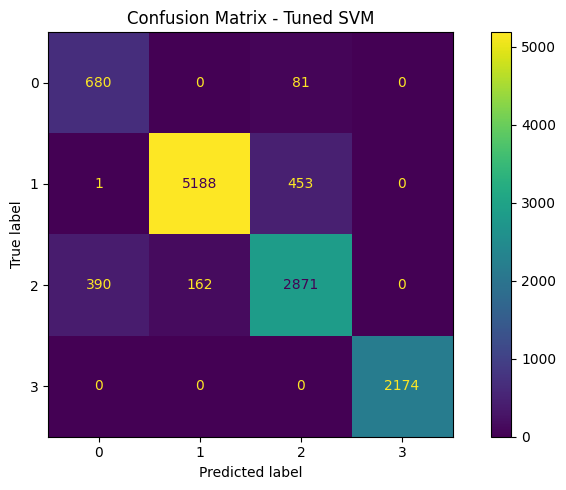

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title("Confusion Matrix - Tuned SVM")
plt.tight_layout()
plt.show()

# **Save the model**

In [ ]:
import pickle


save_path = "/content/drive/My Drive/ML/svm_model.pkl"
with open(save_path, 'wb') as file:
    pickle.dump(best_svm, file)

print(f"Model successfully saved to: {save_path}")

Model successfully saved to: /content/drive/My Drive/ML/svm_model.pkl


# Load the saved model

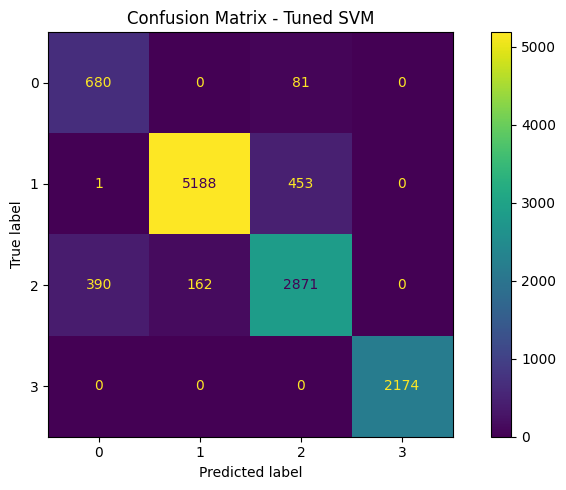

In [ ]:
load_path = "/content/drive/My Drive/ML/svm_model.pkl"
with open(load_path, 'rb') as file:
    loaded_model = pickle.load(file)

# Generate predictions
best_pred = loaded_model.predict(X_test)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title("Confusion Matrix - Tuned SVM")
plt.tight_layout()
plt.show()

In [ ]:
verify_pred = loaded_model.predict(X_test)
print("Loaded model accuracy:", round(accuracy_score(y_test, verify_pred), 4))

Loaded model accuracy: 0.9094


#predict rainfall


In [ ]:
# Define the features the model expects
model_features = [
    'weathercode', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean',
    'shortwave_radiation_sum', 'precipitation_hours', 'windspeed_10m_max',
    'windgusts_10m_max', 'et0_fao_evapotranspiration', 'elevation', 'year',
    'month', 'day', 'day_of_week', 'quarter', 'is_weekend', 'day_length_hours',
    'month_sin', 'month_cos', 'wind_dir_sin', 'wind_dir_cos'
]

# --- Enter your custom values here ---
# Example values provided. Modify these to your desired inputs.
custom_values = {
    'weathercode': 2.0,
    'temperature_2m_max': 28.0,
    'temperature_2m_min': 20.0,
    'temperature_2m_mean': 24.0,
    'apparent_temperature_max': 30.0,
    'apparent_temperature_min': 22.0,
    'apparent_temperature_mean': 26.0,
    'shortwave_radiation_sum': 20.0,
    'precipitation_hours': 0.0,
    'windspeed_10m_max': 10.0,
    'windgusts_10m_max': 25.0,
    'et0_fao_evapotranspiration': 4.0,
    'elevation': 100.0,
    'year': 2023.0,
    'month': 7.0,
    'day': 15.0,
    'day_of_week': 5.0, # Saturday
    'quarter': 3.0,
    'is_weekend': 1.0,
    'day_length_hours': 12.5,
    'month_sin': 0.866,
    'month_cos': -0.5,
    'wind_dir_sin': 0.707,
    'wind_dir_cos': 0.707
}

# Create a DataFrame from the custom values, ensuring correct column order
custom_df = pd.DataFrame([custom_values], columns=model_features)

# Predict using the loaded model
# The 'loaded_model' object is the best_svm pipeline saved earlier.
prediction = loaded_model.predict(custom_df)

# Map the numerical prediction back to meaningful labels
# 0: Heavy Rain, 1: Light Rain, 2: Moderate Rain, 3: No Rain
rainfall_classes = {
    0: "Heavy Rain",
    1: "Light Rain",
    2: "Moderate Rain",
    3: "No Rain"
}

predicted_class = rainfall_classes.get(prediction[0], "Unknown")

print(f"Predicted rainfall class (encoded): {prediction[0]}")
print(f"Predicted rainfall type: {predicted_class}")

Predicted rainfall class (encoded): 3
Predicted rainfall type: No Rain
